In [140]:
import math 
import pandas as pd

from statsbombpy import sb
from mplsoccer import VerticalPitch

In [141]:
df = sb.events(match_id=3869685)

In [142]:
df[['x','y']] = df['location'].apply(pd.Series)
df = df[df['team'] == 'France']

In [143]:
df['newsecond'] = 60 * df['minute'] + df['second']

In [144]:
df = df.sort_values(by=['newsecond'])

In [145]:
df['newsecond']

1          0
12         0
2          0
2389       1
1275       1
        ... 
4401    7447
4286    7457
4243    7509
4403    7558
4288    7558
Name: newsecond, Length: 2035, dtype: int64

In [146]:
df['passer'] = df['player_id']
df['recipient'] = df['passer'].shift(-1)

In [147]:
passes_df = df[df['type'] == 'Pass']

In [148]:
passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna("Successfull")

C:\Users\migue\AppData\Local\Temp\ipykernel_10596\17071806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna("Successfull")


In [149]:
passes_df['pass_outcome']

12      Successfull
13              Out
28      Successfull
29      Successfull
30          Unknown
           ...     
1259     Incomplete
1263     Incomplete
1265    Successfull
1271     Incomplete
1274    Successfull
Name: pass_outcome, Length: 570, dtype: object

In [ ]:
completions = passes_df[passes_df['pass_outcome'] == 'Successfullera']

In [151]:
sub_df = df[df['type'] == 'Substitution']
first_sub = sub_df['newsecond'].min()

In [152]:
first_sub

2432

In [153]:
if first_sub <= (60 * 45):
    first_sub = 60 * 45

In [154]:
completions = completions[completions['newsecond'] < first_sub]

In [155]:
completions.shape

(134, 99)

In [156]:
completions

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,...,team,team_id,timestamp,type,under_pressure,x,y,newsecond,passer,recipient
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:00:00.578,Pass,NaN,61.0,40.1,0,5487.0,NaN
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:01:31.390,Pass,NaN,68.5,5.7,91,6704.0,3026.0
29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:01:33.075,Pass,NaN,72.3,13.4,93,3026.0,6704.0
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:01:55.993,Pass,NaN,61.2,7.0,115,6704.0,5485.0
32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:02:02.182,Pass,NaN,53.1,44.9,122,5485.0,4445.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:44:26.022,Pass,NaN,55.4,28.4,2666,10481.0,5485.0
460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:44:28.474,Pass,NaN,55.2,47.4,2668,5485.0,8519.0
461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:44:30.978,Pass,NaN,47.7,31.4,2670,8519.0,4445.0
462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,France,771,00:44:37.294,Pass,NaN,77.5,71.2,2677,4445.0,22097.0


In [157]:
average_locs_and_count = completions.groupby('passer').agg({'x':['mean'], 'y':['mean','count']})

In [158]:
average_locs_and_count.columns = ['x','y','count']

In [159]:
average_locs_and_count.head()

,x,y,count
passer,,,
3009.0,78.375000,14.025000,8
3026.0,59.828571,25.071429,14
3099.0,12.500000,35.466667,6
3604.0,69.240000,56.020000,5
4445.0,48.929412,68.911765,17


In [160]:
passes_between = completions.groupby(['passer','recipient']).id.count().reset_index()

In [161]:
passes_between.rename({'id':'pass_count'}, axis='columns',inplace=True)

In [162]:
passes_between = passes_between.merge(average_locs_and_count, left_on='passer', right_index=True)
passes_between = passes_between.merge(average_locs_and_count, left_on='recipient', right_index=True, suffixes=['','_end'])

In [163]:
passes_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,3009.0,3026.0,4,78.375000,14.025000,8,59.828571,25.071429,14
1,3009.0,6704.0,3,78.375000,14.025000,8,61.588235,8.841176,17
2,3009.0,8519.0,1,78.375000,14.025000,8,40.505882,27.405882,17
4,3026.0,3009.0,1,59.828571,25.071429,14,78.375000,14.025000,8
5,3026.0,3026.0,1,59.828571,25.071429,14,59.828571,25.071429,14
...,...,...,...,...,...,...,...,...,...
60,10481.0,4445.0,1,57.313333,35.020000,15,48.929412,68.911765,17
61,10481.0,5477.0,1,57.313333,35.020000,15,66.566667,71.955556,9
62,10481.0,5485.0,3,57.313333,35.020000,15,44.215000,52.030000,20
63,10481.0,8519.0,1,57.313333,35.020000,15,40.505882,27.405882,17


In [178]:
passes_between = passes_between[passes_between['pass_count'] >= 4]

In [179]:
def pass_line_template(ax, x, y, end_x, end_y, line_color):
  ax.annotate(
    '',
  xy=(end_y, end_x),
  xytext=(y, x),
  zorder=1,
  arrowprops=dict(arrowstyle="-|>", linewidth=4, color=line_color, alpha=.85)
)
def pass_line_template_shrinkl(ax, x, y, end_x, end_y, line_color, dist_delta=1.2):
 dist = math.hypot(end_x - x, end_y - y)
 angle = math.atan2(end_y-y, end_x-x)
 upd_x= x+ (dist - dist_delta) * math.cos(angle)
 upd_y = y + (dist - dist_delta) * math.sin(angle)
 pass_line_template(ax, x, y, upd_x, upd_y, line_color=line_color)

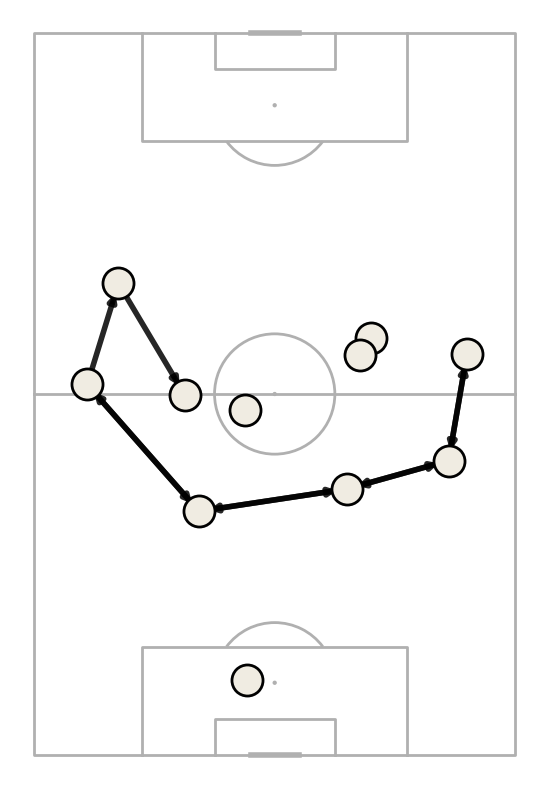

In [180]:
pitch = VerticalPitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12,8))


for index, row  in passes_between.iterrows():
    pass_line_template_shrinkl(ax, row['x'],row['y'], row['x_end'], row['y_end'], 'black')

pitch.scatter(
    average_locs_and_count.x, average_locs_and_count.y, s=500,
    color='#f0ece2', edgecolors ='#010101', linewidth=2, alpha=1, ax=ax, zorder=2
)